In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("heart_disease_uci.csv")

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [2]:
df.shape

(920, 16)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [4]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [5]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [8]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

df = df.drop("id", axis=1)

df["num"] = df["num"].apply(lambda x: 0 if x == 0 else 1)

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = LabelEncoder().fit_transform(df[column].astype(str))

numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns.drop("num")

imputer = SimpleImputer(strategy="median")

df[numeric_columns] = imputer.fit_transform(df[numeric_columns])

print(df.isnull().sum())

age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


In [9]:
X = df.drop("num", axis=1)
y = df["num"]

print(X.shape)
print(y.shape)

(920, 14)
(920,)


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(736, 14)
(184, 14)


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.7989130434782609

Confusion Matrix
[[62 13]
 [24 85]]

Classification Report
              precision    recall  f1-score   support

           0       0.72      0.83      0.77        75
           1       0.87      0.78      0.82       109

    accuracy                           0.80       184
   macro avg       0.79      0.80      0.80       184
weighted avg       0.81      0.80      0.80       184



In [13]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_tree))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_tree))

print("\nClassification Report")
print(classification_report(y_test, y_pred_tree))

Accuracy: 0.782608695652174

Confusion Matrix
[[58 17]
 [23 86]]

Classification Report
              precision    recall  f1-score   support

           0       0.72      0.77      0.74        75
           1       0.83      0.79      0.81       109

    accuracy                           0.78       184
   macro avg       0.78      0.78      0.78       184
weighted avg       0.79      0.78      0.78       184



In [14]:
log_accuracy = accuracy_score(y_test, y_pred_log)
tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Logistic Regression Accuracy :", log_accuracy)
print("Decision Tree Accuracy       :", tree_accuracy)

if log_accuracy > tree_accuracy:
    print("\nBest Model: Logistic Regression")
else:
    print("\nBest Model: Decision Tree")

Logistic Regression Accuracy : 0.7989130434782609
Decision Tree Accuracy       : 0.782608695652174

Best Model: Logistic Regression


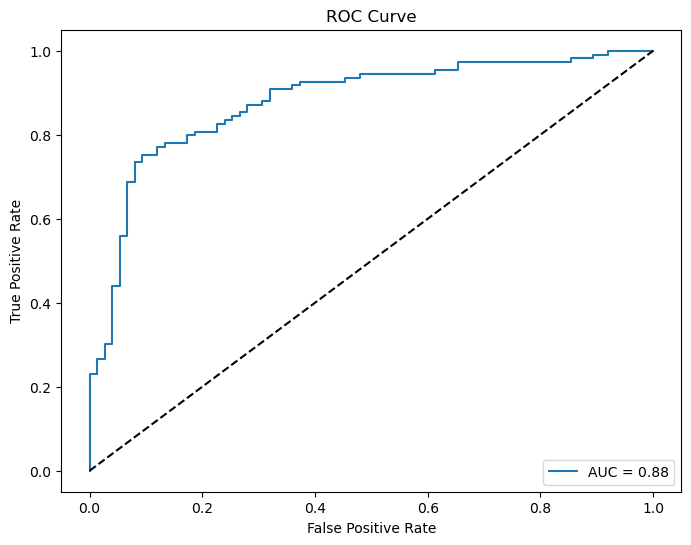

In [15]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = log_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [16]:
import joblib

joblib.dump(log_model, "heart_disease_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [18]:
import pandas as pd

new_patient = pd.DataFrame([[
    63, 1, 0, 3, 145, 233, 1, 2, 150, 0, 2.3, 0, 0, 1
]], columns=X.columns)

new_patient_scaled = scaler.transform(new_patient)

prediction = log_model.predict(new_patient_scaled)

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

No Heart Disease
